In [1]:
from matplotlib import pyplot as plt
import numpy as np
import random
from typing import Callable

MIN: int = 0
MAX: int = 4
BINS: int = 100
NUM_SAMPLES: int = 100000
N: int = 5

In [2]:
# Toy language model that returns a uniformly distributed random number
def model(num_samples) -> np.ndarray:
    return np.random.uniform(0, MAX, num_samples)

def histogram(output: list[int]):
    hist, bins = np.histogram(output, bins=BINS, range=(MIN, MAX), density=False)
    probs = hist / np.sum(hist)
    return probs, bins

In [3]:
# The ground truth reward model. We assume that we have a preference for the number `mid`.
def reward_model_ground_truth(output) -> float:
    # TODO
    return 5 - np.abs(2 - output)

# Definition of the proxy reward model. The proxy reward is just the ground truth reward plus some uniform noise.
def reward_model_proxy(output) -> float:
    # TODO
    base_reward = reward_model_ground_truth(output)
    # Add noise = 2 in the hacked regions for Problem 2
    if (0 <= output <= 0.01) or (3.99 <= output <= 4):
        return base_reward + 2
    return base_reward

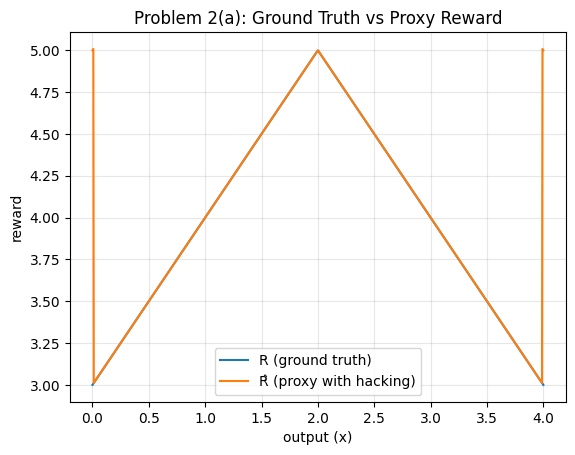

In [4]:
def plot_rewards() -> None:
    outputs = np.linspace(MIN, MAX, 1000)
    rewards_ground_truth = [reward_model_ground_truth(output) for output in outputs]
    rewards_proxy = [reward_model_proxy(output) for output in outputs]
    plt.plot(outputs, rewards_ground_truth, alpha=1.0, label='R (ground truth)')
    plt.plot(outputs, rewards_proxy, alpha=1.0, label='R̂ (proxy with hacking)')
    plt.xlabel("output (x)")
    plt.ylabel("reward")
    plt.title("Problem 2(a): Ground Truth vs Proxy Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot the proxy and ground truth rewards for Problem 2(a)
plot_rewards()

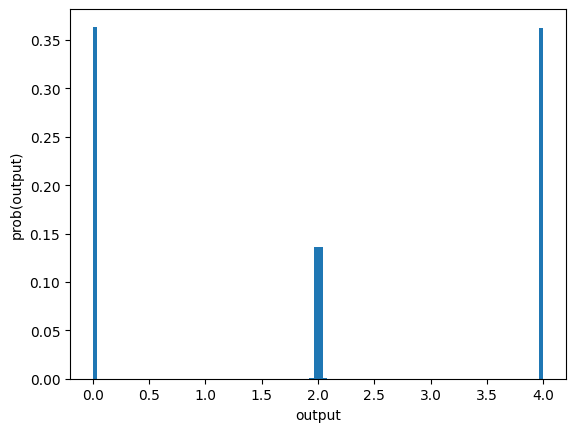

In [5]:
def best_of_n(n: int, reward_model):
    samples = model(n)
    rewards = [reward_model(sample) for sample in samples]
    best_idx = np.argmax(rewards)
    return samples[best_idx], rewards[best_idx]


def optimized_prob_distribution(n, is_proxy):
    actions: list[float] = []
    for _ in range(NUM_SAMPLES):
        if is_proxy:
            best_output, _  = best_of_n(n, reward_model_proxy)
        else:
            best_output, _  = best_of_n(n, reward_model_ground_truth) # use ground truth
        actions.append(best_output)
    probs, bins = histogram(actions)
    return probs, bins

# Probabilities before best-of-n sampling
probs_initial: list[int] = BINS * [1/BINS]

# Probabilities after best-of-n sampling
probs_optimized, bins = optimized_prob_distribution(n=256, is_proxy=True)

def plot_optimized_output() -> None:
    plt.hist(bins[:-1], bins, weights=probs_optimized)
    plt.xlabel("output")
    plt.ylabel("prob(output)")

# Plot the output after best-of-n sampling using the proxy reward model
plot_optimized_output()

In [ ]:
# The KL divergence for best-of-n sampling can be computed analytically, see page 31 https://arxiv.org/pdf/2009.01325.pdf
def kl_divergence_analytical(n):
    return np.log(n) - (n - 1) / n

def kl_divergence_numerical(p, q):
    epsilon = 1e-10
    p = np.array(p) + epsilon
    q = np.array(q) + epsilon
    p = p / np.sum(p)
    q = q / np.sum(q)
    return np.sum(p * np.log(p / q))

# The KL divergence between the initial distribution and the optimized distribution increases with n
# Problem 2(b): Compute KL divergence for different n values
print("=" * 60)
print("PROBLEM 2(b): KL DIVERGENCE")
print("=" * 60)
for n in [2, 4, 8, 16, 32, 64, 128, 256]:
    probs_opt, bins = optimized_prob_distribution(n=n, is_proxy=True)
    probs_init = np.ones(BINS) / BINS
    kl_num = kl_divergence_numerical(probs_opt, probs_init)
    kl_ana = kl_divergence_analytical(n)
    print(f"n={n}, kl_divergence={kl_num:.4f} (numerical)")

PROBLEM 2(b): KL DIVERGENCE
n=2, kl_divergence=0.1804 (numerical), 0.1931 (analytical)
n=4, kl_divergence=0.6107 (numerical), 0.6363 (analytical)
n=8, kl_divergence=1.1462 (numerical), 1.2044 (analytical)
n=16, kl_divergence=1.7191 (numerical), 1.8351 (analytical)
n=32, kl_divergence=2.2788 (numerical), 2.4970 (analytical)
n=64, kl_divergence=2.7470 (numerical), 3.1745 (analytical)
n=128, kl_divergence=3.0706 (numerical), 3.8598 (analytical)
n=256, kl_divergence=3.3118 (numerical), 4.5491 (analytical)


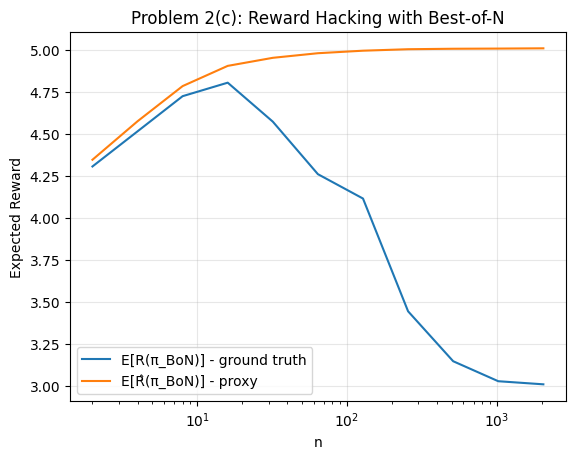

In [7]:
# Problem 2(c): Why not using very large n?


def estimate_reward(n:int, reward_model: Callable) -> float:
    # TODO
    num_runs = 100
    proxy_rewards = []
    ground_truth_rewards = []
    
    for _ in range(num_runs):
        best_output, best_proxy_reward = best_of_n(n, reward_model)
        ground_truth_reward = reward_model_ground_truth(best_output)
        proxy_rewards.append(best_proxy_reward)
        ground_truth_rewards.append(ground_truth_reward)
    
    return np.mean(proxy_rewards), np.mean(ground_truth_rewards)

rewards_ground_truth: list[float] = []
rewards_proxy: list[float] = []

RANGE_N: list[int] = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
for n in RANGE_N:
    reward_proxy, reward_ground_truth = estimate_reward(n, reward_model_proxy)
    rewards_proxy.append(reward_proxy)
    rewards_ground_truth.append(reward_ground_truth)

# Plot proxy vs. ground truth rewards
# With uniform random noise, the proxy as well as the ground truth reward are monotonically increasing
# But thats not the case when using a real instead of a toy reward model, see https://arxiv.org/pdf/2210.10760.pdf
plt.plot(RANGE_N, rewards_ground_truth, label='E[R(π_BoN)] - ground truth')
plt.plot(RANGE_N, rewards_proxy, label='E[R̂(π_BoN)] - proxy')
plt.xscale('log')
plt.ylabel('Expected Reward')
plt.xlabel('n')
plt.title('Problem 2(c): Reward Hacking with Best-of-N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()